In [47]:
%load_ext autoreload
%autoreload 2

import torch
from matplotlib import pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np

from uqct.datasets.utils import get_dataset, KWARGS_LAMINO, KWARGS_LUNG, KWARGS_COMPOSITE

from uqct.metrics import get_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
side_length=128

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
trainSet, testSet_lamino = get_dataset("lamino")
trainSet, testSet_composite = get_dataset("composite")
trainSet, testSet_lung = get_dataset("lung")

In [49]:
images = torch.stack([
    testSet_lamino[0],
    testSet_lamino[1],
    testSet_composite[0],
    testSet_composite[1],
    testSet_lung[2],
    testSet_lung[1],
]).to(device).unsqueeze(1)  # shape: (6, 1, 1, 128, 128)
images.shape

torch.Size([6, 1, 1, 256, 256])

In [50]:
from uqct.ct import compute_sinogram, fbp, forward_ct, fbp_ct, nll, Experiment, uniform_allocation, random_allocation, sinogram_ct, Tomogram, mse_ct, anscombe_transform

min/max of image 0: 0.0/0.5572347640991211
min/max of image 1: 0.0/0.8737594485282898
min/max of image 2: 0.0/0.6761444807052612
min/max of image 3: 0.0/0.716524064540863
min/max of image 4: 0.0/0.5384037494659424
min/max of image 5: 0.0/0.7425925135612488


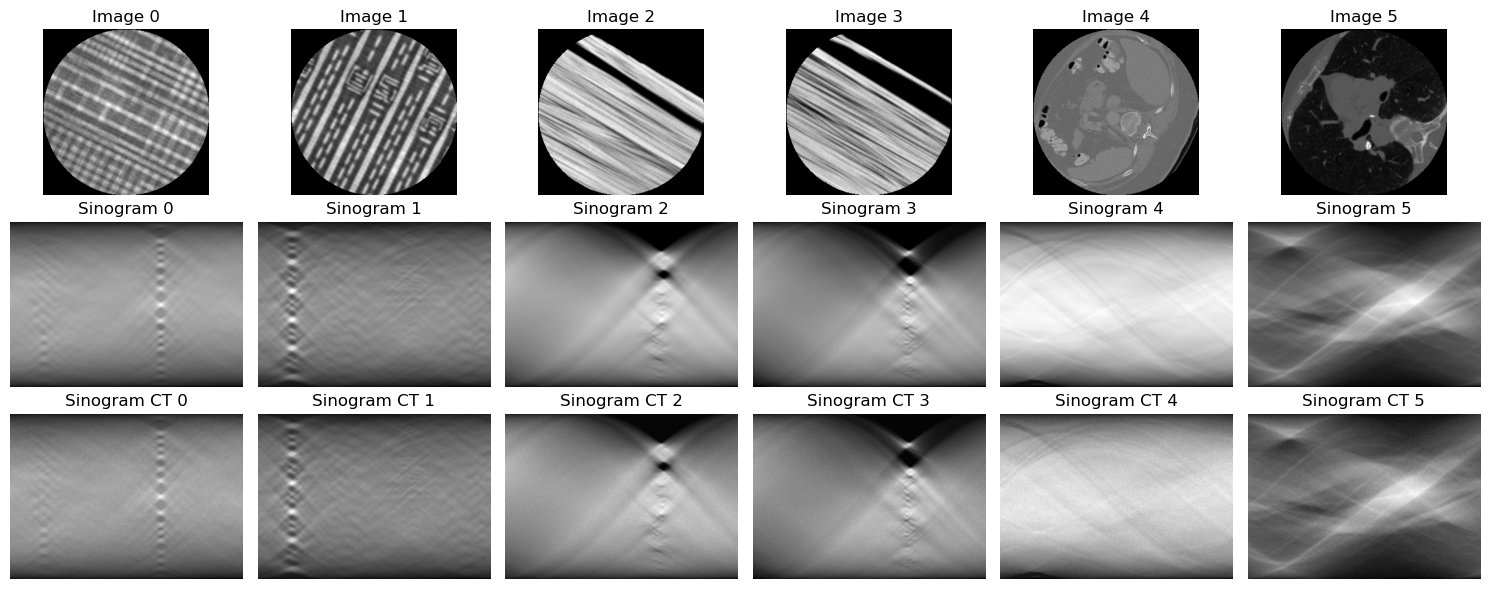

In [51]:
num_angles = 360
sinogram = compute_sinogram(images, angles)

exposure, angles = uniform_allocation(num_angles=num_angles, device=device, exposure=1e6)
measurements = forward_ct(images, angles, exposure=exposure)
measurements_sinogram = sinogram_ct(measurements, exposure)
experiment = Experiment(exposure, measurements, angles)


fig, axes = plt.subplots(3, 6, figsize=(15, 6))
for i in range(6):
    print(f"min/max of image {i}: {images[i].min().item()}/{images[i].max().item()}")
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[1, i].set_title(f'Sinogram {i}')
    axes[1, i].axis('off')

    axes[2, i].imshow(measurements_sinogram[i].cpu().squeeze().T, cmap='gray')
    axes[2, i].set_title(f'Sinogram CT {i}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

sample 0: PSNR=22.04707908630371, min/max of FBP sample 0: 0.0/0.6746582984924316
sample 1: PSNR=23.48984146118164, min/max of FBP sample 1: 0.0/1.0
sample 2: PSNR=22.385944366455078, min/max of FBP sample 2: 0.0/0.9101579189300537
sample 3: PSNR=23.1368465423584, min/max of FBP sample 3: 0.0/0.9006894826889038
sample 4: PSNR=22.252599716186523, min/max of FBP sample 4: 0.0/0.6173396110534668
sample 5: PSNR=26.481809616088867, min/max of FBP sample 5: 0.0/0.7688422799110413


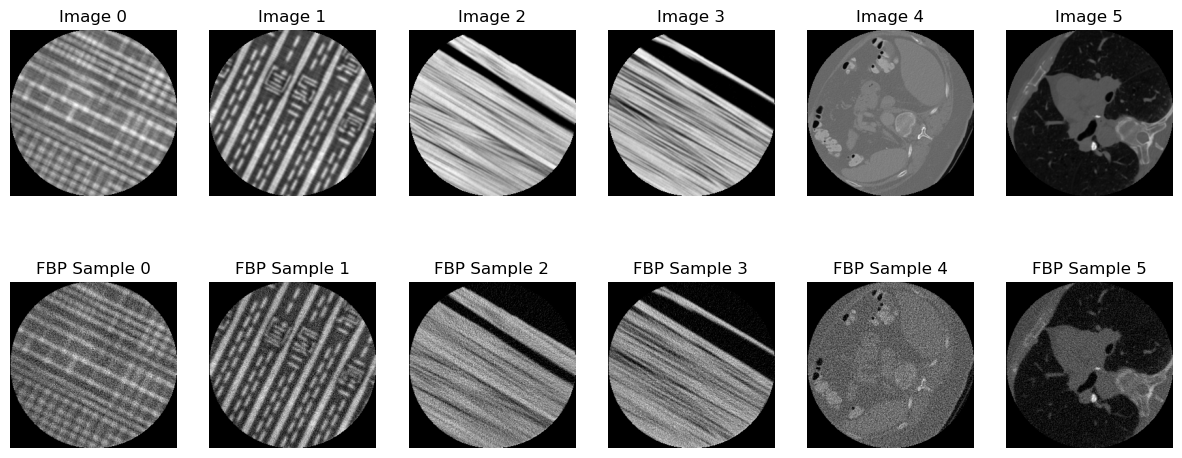

In [52]:
num_angles = 200

sinogram = compute_sinogram(images, angles)

exposure, angles = uniform_allocation(num_angles=num_angles, device=device, exposure=1e6)
measurements = forward_ct(images, angles, exposure=exposure)
measurements_sinogram = sinogram_ct(measurements, exposure)
experiment = Experiment(exposure, measurements, angles)


class FBPModel:
    def __init__(self, experiment, weighted=True):
        self.experiment = experiment
        self.weighted = weighted
    
    def sample(self):
        return fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=self.weighted)
    
fbp_model = FBPModel(experiment)

samples = fbp_model.sample()
samples.shape

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i in range(6):
    metrics = get_metrics(samples[i].squeeze(), images[i])
    print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {samples[i].min().item()}/{samples[i].max().item()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(samples[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'FBP Sample {i}')
    axes[1, i].axis('off')

Iterative Reconstruction:   0%|          | 0/50 [00:00<?, ?it/s]

sample 0: PSNR=21.772232055664062, min/max of FBP sample 0: 0.0/0.9019083976745605
sample 1: PSNR=22.35650634765625, min/max of FBP sample 1: 0.0/1.0
sample 2: PSNR=22.521209716796875, min/max of FBP sample 2: 0.0/0.9132949709892273
sample 3: PSNR=23.322093963623047, min/max of FBP sample 3: 0.0/0.9836059808731079
sample 4: PSNR=20.514175415039062, min/max of FBP sample 4: 0.0/0.7540309429168701


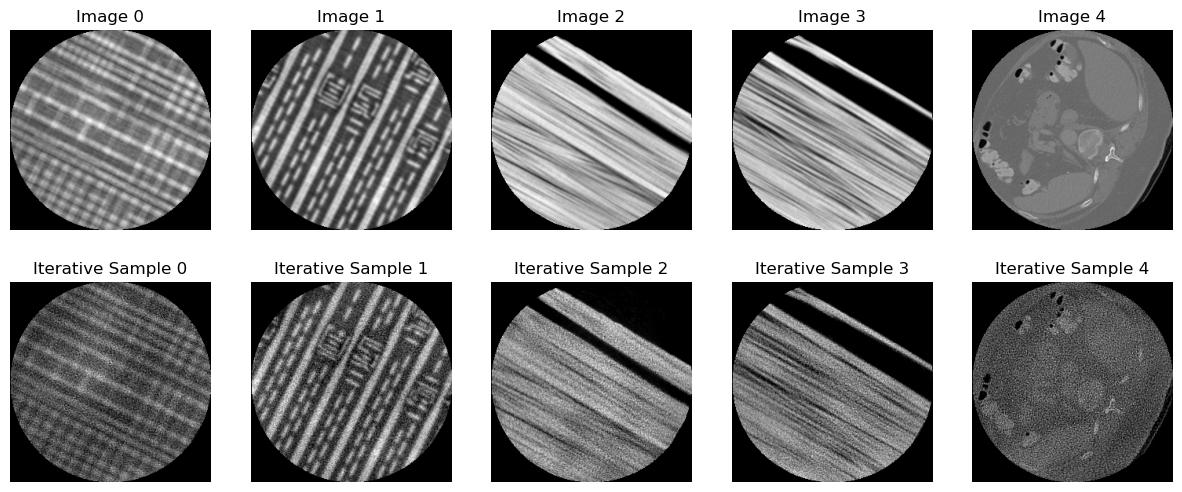

In [53]:
class IterativeModel:
    def __init__(self, experiment, steps=10, init_method='fbp', use_sigmoid=False, lr=1e-1, prior=None, loss = 'nll'):
        self.experiment = experiment
        self.steps = steps
        self.init_method = init_method
        self.use_sigmoid = use_sigmoid
        self.lr = lr
        self._prior = prior
        self.loss = loss

    def prior(self):
        if self.init_method == 'fbp':
            prior = fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=False)
        elif self.init_method == 'fbp_weighted':
            prior = fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=True)
        elif self.init_method == 'zeros':
            prior = torch.zeros((*measurements.shape[:-2], measurements.shape[-1], measurements.shape[-1]), device=measurements.device)
        elif self.init_method == 'random':
            bs = self.experiment.measurements.shape[0:-2]
            prior = torch.randn((*bs, self.experiment.measurements.shape[-1], self.experiment.measurements.shape[-1]), device=self.experiment.measurements.device)
        elif self.init_method == 'prior':
            prior = self._prior.clone()
        return prior

    def sample(self):
        tomogram = Tomogram(prior=self.prior(), use_sigmoid=self.use_sigmoid)

        optimizer = torch.optim.Adam(tomogram.parameters(), lr=self.lr)
        if self.loss == 'nll':
            loss_fn = nll

        else:
            loss_fn = lambda recon, meas, angles, alloc: mse_ct(recon, meas, angles, alloc, vst=anscombe_transform)

        circle_mask = torch.ones(*tomogram().shape[-2:], device=tomogram().device)
        radius = tomogram().shape[-1] // 2
        y, x = torch.meshgrid(torch.arange(tomogram().shape[-2], device=tomogram().device),
                              torch.arange(tomogram().shape[-1], device=tomogram().device),
                              indexing='ij')
        mask = (x - radius) ** 2 + (y - radius) ** 2 <= radius ** 2
        circle_mask[~mask] = 0

        it = tqdm(range(self.steps), desc="Iterative Reconstruction")
        for step in it:
            optimizer.zero_grad()
            loss = loss_fn(tomogram(), self.experiment.measurements, self.experiment.exposure, self.experiment.angles).mean()
            loss.backward()
            optimizer.step()

          # circle mask and clamp
            with torch.no_grad():
                tomogram.image.clamp_(min=0, max=1)
                tomogram.image.mul_(circle_mask)

            it.set_postfix(loss=f"{loss.item():.10f}")

        with torch.no_grad():
            recon = tomogram()

        # recon = torch.clamp(recon, min=0, max=1)
        return recon
    
iterative_model = IterativeModel(experiment, steps=50, use_sigmoid=False, init_method='fbp', lr=1)
samples = iterative_model.sample().detach()


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    metrics = get_metrics(samples[i].squeeze(), images[i])
    print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {samples[i].min().item()}/{samples[i].max().item()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(samples[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Iterative Sample {i}')
    axes[1, i].axis('off')

plt.show()


Model path: '/mydata/chip/shared/checkpoints/ddpm_DDPM_Chip_Tomograms_128.pt' doesn't exists
model loaded from checkpoint ../checkpoints/ddpm_DDPM_Chip_Tomograms_128.pt
torch.Size([30, 1, 256, 256])


  0%|          | 0/51 [00:00<?, ?it/s]

0it [00:00, ?it/s]

sample 0: PSNR=21.993938446044922, min/max of FBP sample 0: 0.0/0.8564739227294922
sample 1: PSNR=21.92670440673828, min/max of FBP sample 1: 0.0/0.9839948415756226
sample 2: PSNR=22.164230346679688, min/max of FBP sample 2: 0.0/0.981322169303894
sample 3: PSNR=21.840835571289062, min/max of FBP sample 3: 0.0/0.9733438491821289
sample 4: PSNR=22.03326416015625, min/max of FBP sample 4: 0.0/0.788193941116333


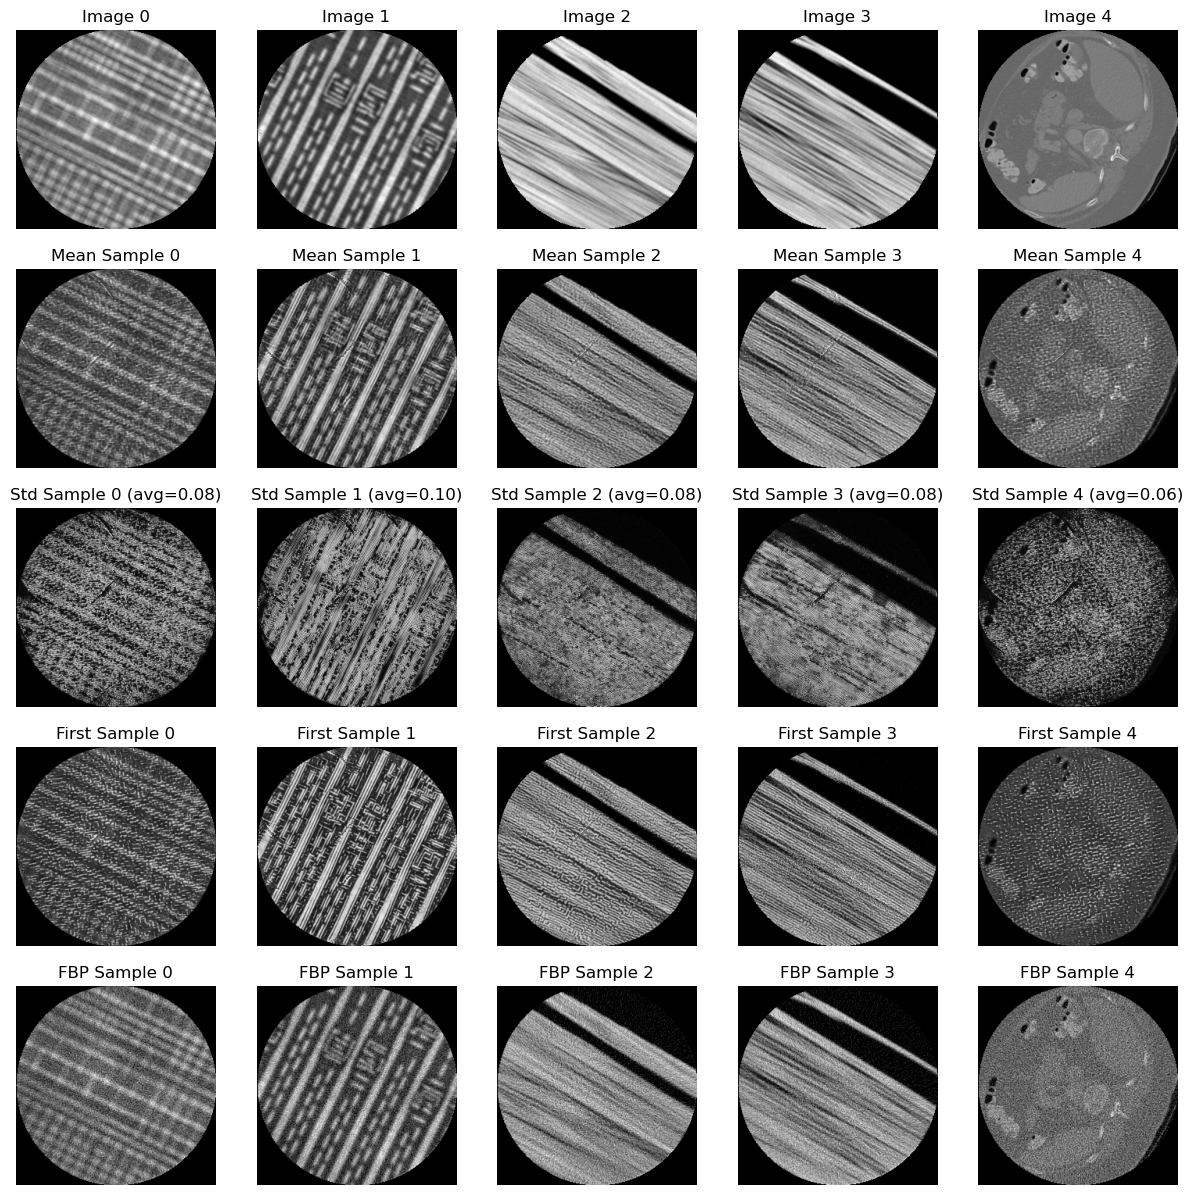

In [54]:
# sampling
from uqct.models.tomographic_diffusion import TomographicDiffusion
from diffusers import DDPMScheduler
from diffusers import UNet2DModel

def get_diff_unet_model(checkpoint_path, im_size=128, device='cuda'):
    model = UNet2DModel(
            sample_size=im_size,  # the target image resolution
            in_channels=1,  # the number of input channels, 3 for RGB images
            out_channels=1,  # the number of output channels
            layers_per_block=2,  # how many ResNet layers to use per UNet block
            block_out_channels=(64, 64, 128, 128, 256, 256),  # the number of output channels for each UNet block
            down_block_types=(
                "DownBlock2D",  # a regular ResNet downsampling block
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
                "DownBlock2D",
            ),
            up_block_types=(
                "UpBlock2D",  # a regular ResNet upsampling block
                "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
            ),
        ).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"model loaded from checkpoint {checkpoint_path}")
    return model


def get_diffusion_samples(model, target, loss_fct=None, inpainting_fct=None, hr_sinogram=None, lr_sinogram=None, batch_size=10, device=None, verbose=False, num_samples=20, buffer=5, use_sigmoid=False, t_start=999, sgd_steps=None, lr=None, num_steps=100):
    if lr is None:
        lr = [0.01, 0.005]
    if sgd_steps is None:
        sgd_steps = [100, 50]
    noise_scheduler = DDPMScheduler(num_train_timesteps=1000, clip_sample=False)

    # target = torch.ones((model.sample_size, model.sample_size))
    # x_t = noise_scheduler.add_noise(
    #     target.repeat(num_samples, 1, 1, 1), 
    #     torch.randn_like(target.repeat(num_samples, 1, 1, 1)), 
    #     torch.LongTensor([t_start])
    # ).to(device)
    x_t = noise_scheduler.add_noise(
        target,
        torch.randn_like(target),
        torch.LongTensor([t_start])
    ).to(device)


    # td = TomographicDiffusion(
    #     (num_samples, model.sample_size, model.sample_size), model, use_sigmoid=use_sigmoid, 
    #     buffer=buffer, fourier_magnitude=None
    # ).to(device)
    print(target.shape)

    td = TomographicDiffusion(
        target.shape, model, use_sigmoid=use_sigmoid, 
        buffer=buffer, fourier_magnitude=None
    ).to(device)

    images = td.guided_diffusion_pipeline(
        x_t, t_start, 0, noise_scheduler, num_steps,
        loss_fct=loss_fct,
        inpainting_fct=inpainting_fct,
        batch_size=batch_size, #min(10, len(hr_sinogram)), 
        verbose=verbose, 
        sgd_steps=sgd_steps, 
        lr=lr, 
        with_finetuning=False
    )

    return images

# Find checkpoint
CKPT_DIR_CANDIDATES = (Path(x) / "ddpm_DDPM_Chip_Tomograms_128.pt" 
                       for x in ("/mydata/chip/shared/checkpoints/", "../checkpoints"))
while not (model_path := next(CKPT_DIR_CANDIDATES)).exists():
    print(f"Model path: '{model_path}' doesn't exists")

    
diffusion_model = get_diff_unet_model(model_path, im_size=side_length, device=device)


# using t_start=300 for better results
target = torch.ones((diffusion_model.sample_size, diffusion_model.sample_size), device=device)

def guidance_loss(measurements, exposure, angles):
    """
    Define a loss function for the diffusion model.
    This can be used to guide the diffusion process.
    """
    def loss_fn(image):
        loss =  nll(image, measurements, exposure, angles)
        return loss[0]
    return loss_fn

def inpainting_fct(image):
    circle_mask = torch.ones((image.shape[-2], image.shape[-1]), device=image.device)
    radius = image.shape[-1] // 2
    y, x = torch.meshgrid(torch.arange(image.shape[-2], device=image.device),
                          torch.arange(image.shape[-1], device=image.device),
                          indexing='ij')
    mask = (x - radius) ** 2 + (y - radius) ** 2 <= radius ** 2
    circle_mask[~mask] = 0
    image = image * circle_mask # Apply
    return torch.clip(image, min=0, max=1)




# # target = recon_fbp_weighted
# samples = get_diffusion_samples(diffusion_model, target, loss_fct=guidance_loss(experiment.measurements, experiment.exposure, experiment.angles), num_samples=5, device=device, verbose=True, buffer=5, t_start=200, lr=1e-1, sgd_steps=10, num_steps=20, inpainting_fct=inpainting_fct)

# # plot samples
# fig, ax = plt.subplots(1, 5, figsize=(20, 4))
# for i in range(5):
#     ax[i].imshow(samples[i].cpu().squeeze().numpy(), cmap='gray')
#     ax[i].axis('off')
#     print(f"Sample {i} min/max: {samples[i].min().item()}/{samples[i].max().item()}")
# plt.show()


class DiffusionModel:
    def __init__(self, diffusion_model, experiment, num_samples=5, t_start=999, sgd_steps=None, lr=None, num_steps=50, buffer=5):
        self.diffusion_model = diffusion_model
        self.experiment = experiment
        self.num_samples = num_samples
        self.t_start = t_start
        self.sgd_steps = sgd_steps
        self.lr = lr
        self.num_steps = num_steps
        self.buffer = buffer

    def sample(self, extra_guidance_loss=None, num_steps=None, sgd_steps=None, lr=None):
        num_samples = self.num_samples
        t_start = self.t_start
        if sgd_steps is None:
            sgd_steps = self.sgd_steps
        if lr is None:
            lr = self.lr
        if num_steps is None:
            num_steps = self.num_steps


        target = fbp_ct(self.experiment.measurements, self.experiment.angles, self.experiment.exposure, weighted=True)

        # expand second dimension to match num_samples
        target = target.expand(-1, num_samples, -1, -1, -1)
        # print(target.shape)
        batch_dims, data_dims = target.shape[:-3], target.shape[-3:]
        target = target.reshape(-1, *data_dims)


        def guidance_loss(measurements, exposure, angles):
            """
            Define a loss function for the diffusion model.
            This can be used to guide the diffusion process.
            """
            def loss_fn(image):
                # print(image.shape)
                image = image.view((*batch_dims, *data_dims))
                loss = nll(image, measurements, exposure, angles).mean()

                if extra_guidance_loss is not None:
                    loss += extra_guidance_loss(image)
                return loss
            return loss_fn

        
        return get_diffusion_samples(
            self.diffusion_model,
            target,
            loss_fct=guidance_loss(self.experiment.measurements, self.experiment.exposure, self.experiment.angles) if self.sgd_steps else None,
            inpainting_fct=inpainting_fct,
            batch_size=num_samples,
            device=self.experiment.measurements.device,
            verbose=True,
            num_samples=num_samples,
            buffer=self.buffer,
            use_sigmoid=False,
            t_start=t_start,
            sgd_steps=sgd_steps,
            lr=lr,
            num_steps=num_steps
        ).view((*batch_dims, *data_dims))
    
exposure = 1e6
num_angles = 360
exposure, angles = uniform_allocation(num_angles=num_angles, device=device, exposure=exposure)
measurements = forward_ct(images, angles, exposure=exposure)
measurements_sinogram = sinogram_ct(measurements, exposure)
experiment = Experiment(exposure, measurements, angles)

fbp_model = FBPModel(experiment)
recon_fbp = fbp_model.sample()


total_steps = 1000
diffusion_steps = 50
sgd_steps = round(total_steps / diffusion_steps)
model = DiffusionModel(diffusion_model, experiment, num_samples=5, sgd_steps=sgd_steps, lr=1e-1, num_steps=diffusion_steps, buffer=0)
samples = model.sample().detach()

samples_mean = samples.mean(dim=1)
samples_std = samples.std(dim=1)
samples_first = samples[:, 0]

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i in range(5):
    metrics = get_metrics(samples_mean[i].squeeze(), images[i])
    print(f"sample {i}: PSNR={metrics['PSNR']}, min/max of FBP sample {i}: {samples[i].min().item()}/{samples[i].max().item()}")

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')

    axes[1, i].imshow(samples_mean[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Mean Sample {i}')
    axes[1, i].axis('off')

    axes[2, i].imshow(samples_std[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title(f'Std Sample {i} (avg={samples_std[i].mean().item():.2f})')
    axes[2, i].axis('off')

    axes[3, i].imshow(samples_first[i].cpu().squeeze(), cmap='gray')
    axes[3, i].set_title(f'First Sample {i}')
    axes[3, i].axis('off')

    axes[4, i].imshow(recon_fbp[i].cpu().squeeze(), cmap='gray')
    axes[4, i].set_title(f'FBP Sample {i}')
    axes[4, i].axis('off')